# NN Testing with various run splits

In [516]:
import sys
import os

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
sys.path.append(os.path.abspath('..'))
from venus_ml import VenusDataset
import matplotlib.pyplot as plt
import torch 
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Dataset

In [517]:
run1, run2 = '00', '13'

In [518]:
def get_features(names, mean=True, std=False):
    out_list = []
    for name in names:
        if mean:
            out_list.append(name + "_mean")
        if std:
            out_list.append(name + "_std")
    return out_list

In [519]:
target = ["fcv1_i_mean"]
feature_groups = {
    "S": ["inj_mbar", "bias_v", "bias_i", "extraction_i"],
    "M": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i"],
    "L": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i", "inj_i", "ext_i", "mid_i", "sext_i", "x_ray_source", "x_ray_exit"],
}

In [520]:
from users.ezra.venus_ml import generate_lag_fn, create_differential_features, generate_smoother

data_set_config = {
    "file_path": "../minmax_watch_data.parquet",
    "input_columns": [],
    "output_columns": target,
    "run_selection": (run1, run2),
    # "transforms": [generate_smoother(2)]
}
datasets = {}

for feature_group in feature_groups.keys():
    data_set_config["input_columns"] = get_features(feature_groups[feature_group], std=False)
    datasets[feature_group] = VenusDataset(**data_set_config)


### Helper Functions

In [521]:
def one_run(dataset, run1):
    return dataset.get_run_splits((run1,))  # train_x, train_y, validation_x, validation_y

def both_run(dataset, run1, run2):
    return dataset.get_run_splits((run1, run2)) # train_x, train_y, validation_x, validation_y

def train_and_test(dataset, run1, run2):
    data = dataset.get_runs((run1,run2))
    return data[run1][0], data[run1][1], data[run2][0], data[run2][1] # train_x, train_y, validation_x, validation_y

def get_dataloader(x, y, batch_size=8, shuffle=True): 
    x, y = torch.from_numpy(x).float(), torch.from_numpy(y).float()
    data = TensorDataset(x, y)
    return DataLoader(data, batch_size=batch_size, shuffle=shuffle)

def standardize_features(train_x, test_x):
    mu = train_x.mean(0)
    std = train_x.std(0)
    train_x = (train_x - mu)/std
    test_x = (test_x - mu)/std
    return train_x, test_x

# Neural Network

In [522]:
class Net(nn.Module):
    """
    Neural network regressor w/flexible hyperparameters
    """
    def __init__(self, input_dim, hidden_dim, num_layers, dropout=0):
        super().__init__()
        self.num_layers = num_layers
        layers = [nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(dropout)]
        nn.init.kaiming_normal_(layers[0].weight, mode='fan_out', nonlinearity='relu')
        for _ in range(1, num_layers):
            layer = nn.Linear(hidden_dim, hidden_dim)
            nn.init.kaiming_normal_(layer.weight, mode='fan_out', nonlinearity='relu')
            layers += [layer,nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(dropout)]

        layers += [nn.Linear(hidden_dim, 1)]
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)


### Helper Functions

In [523]:
lrs = []
def train_model(model, loaders, optimizer, epochs, criterion, scheduler, device='cpu', lr=1e-3):
    train_loader, val_loader = loaders
    model.to(device)
    optimizer = optimizer(model.parameters(), lr=lr)
    criterion = criterion()
    mse = nn.MSELoss()

    # Define lambda function for linearly decreasing LR
    lr_lambda = lambda epoch: 1 - epoch / epochs
    scheduler = scheduler(optimizer, lr_lambda=lr_lambda)

    train_losses = []
    val_losses = []

    # Using tqdm for the progress bar
    epoch_bar = tqdm(range(epochs), desc="Training", total=epochs, position=0)

    for epoch in epoch_bar:
        
        model.eval()
        val_loss = 0.0
        train_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                ms_e = mse(outputs, labels)
                val_loss += ms_e.item() * inputs.size(0)
        
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        
        
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            ms_e = mse(outputs, labels)
            train_loss += ms_e.item() * inputs.size(0)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            lrs.append(optimizer.param_groups[0]["lr"])
            
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        scheduler.step()

       



        # Update progress bar
        train = format(train_loss, "e")
        val = format(val_loss, "e")
        lr = format(optimizer.param_groups[0]["lr"], "e")
        epoch_bar.set_postfix({'Train Loss': f'{train}', 'Val Loss': f'{val}', 'LR': f'{lr}'})
    
    return train_losses, val_losses


In [524]:
from sklearn.ensemble import ExtraTreesRegressor


def compare_groups(config, data_args, train_config, standardize=False):
    results = {}
    for group, dataset in datasets.items():
        train_x, train_y, test_x, test_y = data_args["fn"](dataset, **data_args["params"])
        if standardize:
            train_x, test_x = standardize_features(train_x, test_x)
        input_dim = train_x.shape[1]
        model = Net(input_dim, **config)
        
        rf = RandomForestRegressor(n_estimators=300, n_jobs=-1)
        rf.fit(train_x, train_y.ravel())
        preds = rf.predict(test_x)
        mse = mean_squared_error(test_y.ravel(), preds)
        
        train_loader = get_dataloader(train_x, train_y, batch_size=64)
        test_loader = get_dataloader(test_x, test_y, shuffle=False, batch_size=512)
        train_losses, val_losses = train_model(model, (train_loader, test_loader), **train_config)
        results[group] = train_losses, val_losses, mse
    return results

In [525]:
def plot_results(results, y_scale="log"):
    fig, axes = plt.subplots(3, 1, figsize=(20, 20))
    for i, (group, (train_losses, val_losses, rf)) in enumerate(results.items()):
        x_axis = range(len(train_losses))
        axes[i].plot(x_axis, train_losses, label="Train")
        axes[i].plot(x_axis, val_losses, label="Val")
        axes[i].plot(x_axis, [rf] * len(train_losses), label="Random Forest")
        axes[i].set_yscale(y_scale)
        axes[i].set_ylim(1e-4)
        axes[i].legend(loc="upper right")
        train = format(train_losses[-1],"e")
        val = format(val_losses[-1],"e")
        axes[i].set_title(f"Group {group} | Train Error: {train} | Validation Error: {val} | RF Error: {rf}") 
    plt.tight_layout() 
    plt.show()

# Initial Testing
Make sure it can overfit, try out hyperparams to lower loss

In [526]:
model_config = {
    "hidden_dim": 256,
    "num_layers": 1,
    "dropout": 0
}

data_args = {
    "fn": one_run,
    "params": {
        "run1":run1,
        # "run2":run2
    }
}

train_config = {
    "device":"cpu",
    "epochs": 500,
    "optimizer": torch.optim.Adam,
    "lr": 1e-3,
    "criterion": nn.MSELoss,
    "scheduler":torch.optim.lr_scheduler.LambdaLR
}

results = compare_groups(model_config, data_args, train_config, standardize=True)
for group, (train_losses, val_losses, mse) in results.items():
    print(f"Group: {group}| Train Error: {format(train_losses[-1], 'e')} | Validation Error: {format(val_losses[-1], 'e')} | RF Error: {format(mse, 'e')}") 

Training: 100%|██████████| 500/500 [00:18<00:00, 27.14it/s, Train Loss=7.373018e-04, Val Loss=8.876612e-04, LR=0.000000e+00]

Group: S| Train Error: 9.744648e-04 | Validation Error: 4.787087e-04 | RF Error: 6.217910e-04
Group: M| Train Error: 7.698959e-04 | Validation Error: 5.137227e-04 | RF Error: 4.825561e-04
Group: L| Train Error: 7.373018e-04 | Validation Error: 8.876612e-04 | RF Error: 5.477469e-04


In [527]:
x_axis = range(len(lrs[:len(lrs)//3]))
# plt.plot(x_axis, lrs[:len(lrs)//3])

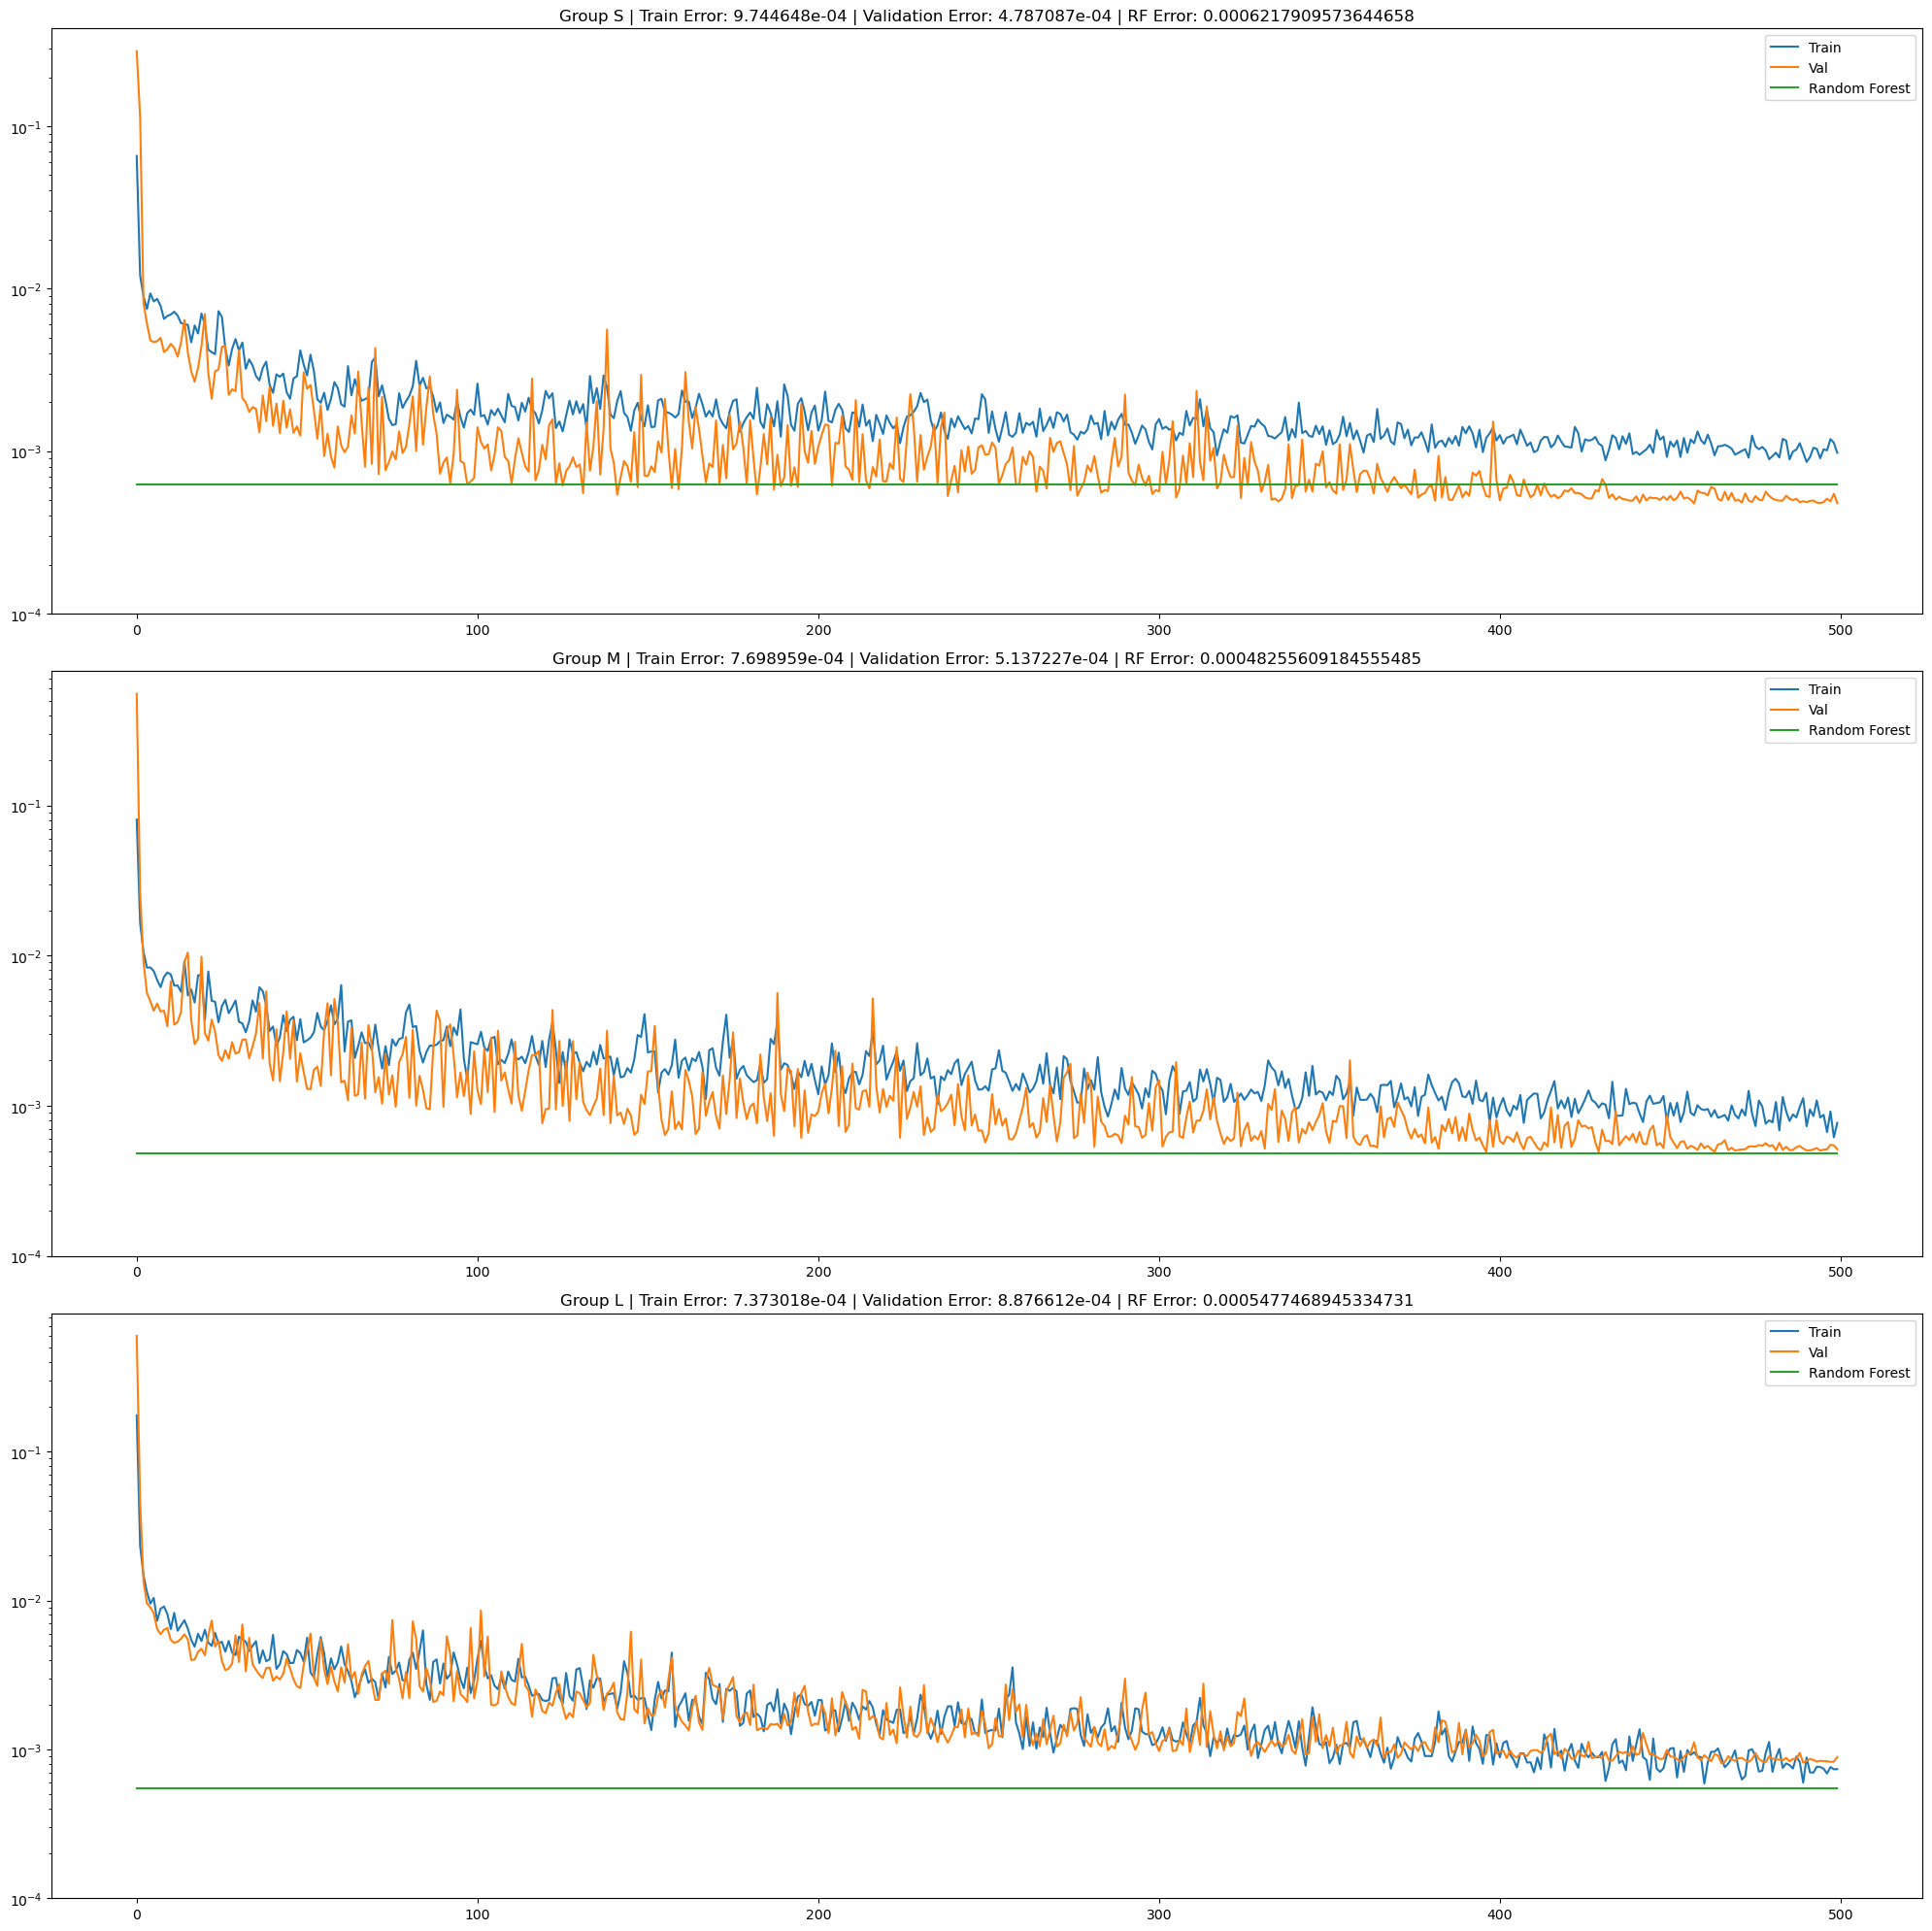

In [528]:
plot_results(results, y_scale="log")